## Create a circuit


For example a circuit to calculate the ground state energy of the following $N$-site spin-1/2 Hamiltonian:

\begin{equation}
\hat{\mathscr{H}}=J \sum_{\langle ij\rangle} \hat{Z}_i \hat{Z}_j+\sum_i\left(h_x \hat{X}_i+h_z \hat{Z}_i\right),
\end{equation}

where $J$ is the coupling strength, $h_x$ and $h_z$ are the magnetic field strengths, and $\langle ij\rangle$ denotes the sum over all nearest neighbor pairs.


As a simple example we could have a 4-site spin-1/2 system with the given topology:

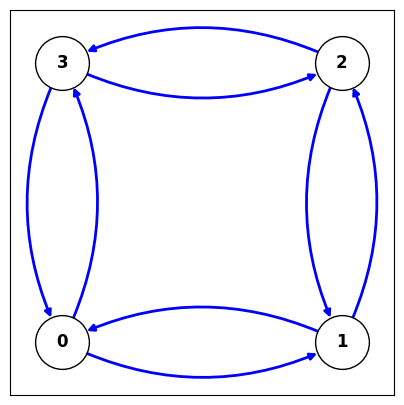

In [ ]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

ax = plot_topology(topology)

The Hamiltonian of the system is given by
\begin{equation}
\hat{\mathscr{H}}=J (Z_0Z_1 + Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_0) + h_x (X_0 + X_1 + X_2 + X_3) + h_z (Z_0 + Z_1 + Z_2 + Z_3),
\end{equation}

where $P_i$ means that the Pauli operator $P_i$ is applied to the $i$-th site and the rest of the sites are acted on by the identity operator.


Since it is generally not feasible to implement the time evolution operator

\begin{equation}
\hat{\mathscr{U}}(t) = e^{-i \hat{\mathscr{H}} t / \hbar},
\end{equation}

which solves the Schrödinger equation exactly, we use an Ansatz to approximate the time evolution operator. The following Ansatz is inspired by the Trotter decomposition. The Trotter decomposition is a method for approximating the time evolution operator by breaking it down into a product of smaller time evolution operators. The Ansatz is given by

\begin{equation}
\mathcal{U}\left(\theta_l\right)=\mathcal{U}^x\left(\gamma_l\right) \mathcal{U}^z\left(\beta_l\right) \mathcal{U}^{z z}\left(\alpha_l\right),\\
\end{equation}
where
\begin{align*}
\mathscr{U}^{z z}(\alpha) &=\exp \left(-i \frac{\alpha}{2} \sum_{\langle\ddot{j}\rangle} Z_i Z_j\right) \\
\mathscr{U}^z(\beta)      &=\exp \left(-i \frac{\beta}{2} \sum_i Z_i\right) \\
\mathscr{U}^x(\gamma)     &=\exp \left(-i \frac{\gamma}{2} \sum_i X_i\right).
\end{align*}

Since the terms in each sum consist of Pauli operators that either act on different qubits or are the same Pauli on overlapping qubits, they all commute. Therefore, the exponential of the sum factorizes exactly into a product of exponentials of the individual terms. For example,

$$
e^{-i \frac{\alpha}{2} \sum_{\langle i j\rangle} Z_i Z_j}=\prod_{\langle i j\rangle} e^{-i \frac{\alpha}{2} Z_i Z_j},
$$

and similarly for the $Z$ - and $X$-blocks.
This reduces the complicated global operator to a set of simple one- and two-qubit rotations that can be directly implemented as standard quantum gates.

The parameters $\alpha_l$, $\beta_l$, and $\gamma_l$ are the parameters of the circuit. They need to be optimized to minimize the error between the exact time evolution operator and the Ansatz. This can be done by the VQE algorithm. The index $l$ describes the layer of the circuit. Repeating it an infinite number of times and taking the limit $\Delta t \rightarrow 0$ would give the exact time evolution operator. However, this is not feasible in practice, since we have limited resources and the depth of the circuited is always limited due to noise. Instead, we use a finite number of layers and a finite time step $\Delta t$ to approximate the time evolution operator.

Here we use only one layer of the circuit. The following code cretes the circuit and the Hamiltonian.

In [2]:
from src.VQE_functions import MFIM_Hamiltonian, build_hva_layers

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)

hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

values = {p: v for p, v in zip(params, [0.1, 0.2, 0.3])}
qc_bound = hva_layers.assign_parameters(values)

qc_bound.draw(fold=-1)

┌───┐┌─────────┐┌─────────┐                                                          
q_0: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├──■───────────────■────■──────────────────────────■───────
     ├───┤├─────────┤├─────────┤┌─┴─┐┌─────────┐┌─┴─┐  │                          │       
q_1: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├┤ X ├┤ Rz(0.1) ├┤ X ├──┼───────■──────────────────┼────■──
     ├───┤├─────────┤├─────────┤└───┘└─────────┘└───┘  │     ┌─┴─┐   ┌─────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├──■───────────────■────┼─────┤ X ├───┤ Rz(0.1) ├──┼──┤ X ├
     ├───┤├─────────┤├─────────┤┌─┴─┐┌─────────┐┌─┴─┐┌─┴─┐┌──┴───┴──┐└─────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├┤ X ├┤ Rz(0.1) ├┤ X ├┤ X ├┤ Rz(0.1) ├───────────┤ X ├─────
     └───┘└─────────┘└─────────┘└───┘└─────────┘└───┘└───┘└─────────┘           └───┘

The parameters above were chosen randomly. To obtain the optimal parameters you can use a VQE algorithm. The main idea for finding the ground state and ground state energy is the fact that for any given input state $|\psi\rangle$ the expectation value of the Hamiltonian is bigger equal then the real ground state energy $E_{gs}$:

\begin{equation}
\langle \psi | H | \psi \rangle \geq E_{gs}
\end{equation}


Therefore we can start with a random state (here we start with $\psi_0\rangle=|+\rangle^{\otimes n}$) and random parameters for $\alpha, \beta, \gamma$. Then we measure the expectation value of the Hamiltonian for the current state and parameters. Then we vary the parameters and repeat the process until the expectation value converges. The parameters in the last iteration are the optimal parameters to approximate the ground state (energy) with respect to the number of layers we used.

In this example we will use the statevector simulator provided by Qiskit to have an optimal solution. 

In [ ]:
from src.VQE_functions import optimize_energy, init_parameters
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)

# FakeBackend laden
fake_backend = FakeWashingtonV2()

# NoiseModel aus FakeBackend extrahieren
noise_model = NoiseModel.from_backend(fake_backend)

# AerSimulator mit Noise
backend_noisy = AerSimulator(noise_model=noise_model)

coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)
#backend = AerSimulator()

eigvals = eigh(Hamiltonian.to_matrix(), eigvals_only=True)
exact_energy = np.min(eigvals)

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

print("Optimierung startet...")

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, topology=topology, num_layers=num_layers, backend=backend_noisy, mode="measurement", method="Powell",bounds = bounds)
print("Optimierung fertig.")


print("Measured energy: ",energy)
print("Exact energy: ", exact_energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("initial parameters: ",initial_params)
print("optimale Parameter: ", opt_params)

Optimierung startet...
Optimierung fertig.
Measured energy:  -7.648
Exact energy:  -8.66595245727459
Relative error:  11.74657329697298 %
initial parameters:  [1, 1, 1]
optimale Parameter:  [ 1.17019173 -1.44809577  1.33253413]


## Studies on the VQE error

Scanning the ground-state energy \(E_0(h_x,h_z)\) and the VQE error across the $(h_x,h_z)$-plane shows where the VQE algorithm works reliably and let's us quantify how strongly the optimal ansatz parameters $\{\alpha,\beta,\gamma\}$ depend on $h_x$ and $h_z$.

Scanning (hx,hz):   0%|          | 0/225 [00:00<?, ?it/s]

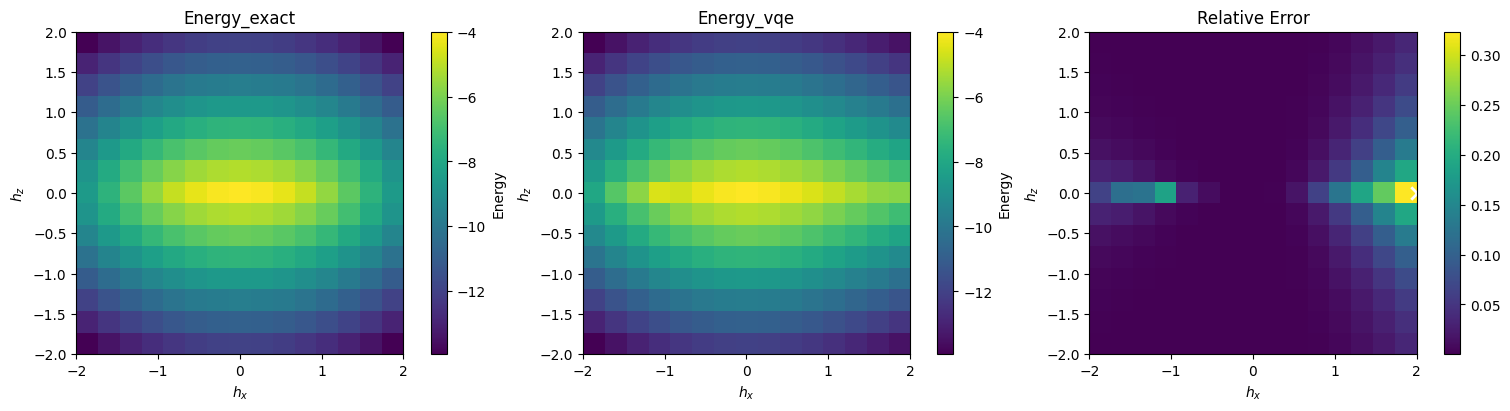

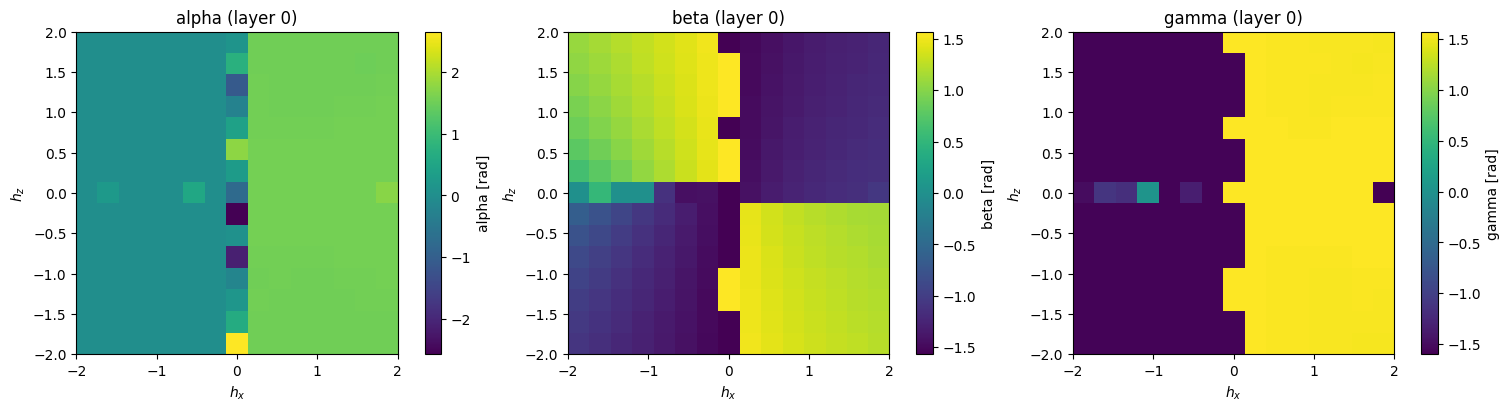

In [4]:
import numpy as np
import sys; sys.path.append('../..')
from src.VQE_functions import run_scan
from src.plot_helpers import plot_metrics, plot_params
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2

# Parameter
J = -1
num_layers = 1
N = 20  # Anzahl Punkte pro Achse
topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

bounds = [(-np.pi, np.pi)] * 3*num_layers

fake_backend = FakeWashingtonV2()

result = run_scan(J=-1, num_layers=1, topology=topology, N=15, method="Powell", bounds=bounds, mode="statevector", backend=fake_backend, initial_layout=[0,1,2,3])

fig_m, axs_m = plot_metrics(result)
fig_p, axs_p = plot_params(result, layer=0)

In [5]:
from src.plot_helpers import get_scan_value

param_dict = {}

for hx1 in [-1,1]:
    for hz1 in [-1,1]:
        params1 = get_scan_value(result, hx=hx1, hz=hz1, key="Opt_parameters")
        err1 = get_scan_value(result, hx=hx1, hz=hz1, key="Rel_error")

        param_dict[(hx1, hz1)] = {
            "rel_error": float(err1),
            "params": params1
        }

        print(f"Parameter für hx = {hx1} und hz = {hz1}: {params1} und rel. Fehler {err1}")

Parameter für hx = -1 und hz = -1: [ 6.19456598e-04 -1.23684762e+00 -1.57040517e+00] und rel. Fehler 0.0007456875493539308
Parameter für hx = -1 und hz = 1: [ 5.56346007e-04  1.23684757e+00 -1.57043859e+00] und rel. Fehler 0.0007456868343629149
Parameter für hx = 1 und hz = -1: [1.53190912 1.30817959 1.54929407] und rel. Fehler 0.013056799254714799
Parameter für hx = 1 und hz = 1: [ 1.53109154 -1.30825273  1.54861992] und rel. Fehler 0.013054910095117845


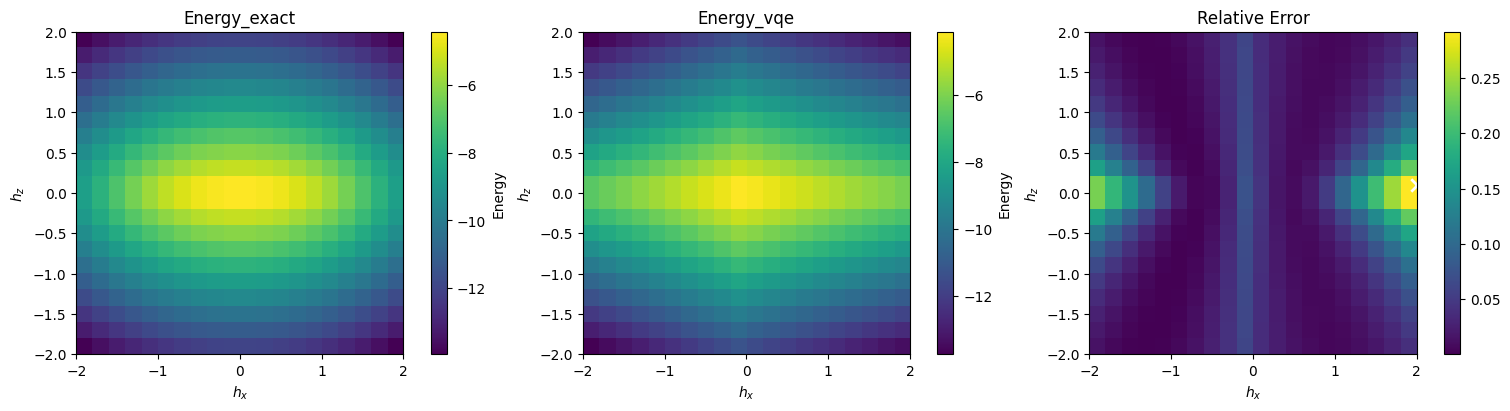

In [6]:
from scipy.linalg import eigh
from qiskit.quantum_info import Statevector
from src.VQE_functions import MFIM_Hamiltonian, build_hva_layers

J = -1
num_layers = 1

hx_vals = np.linspace(-2, 2, N)
hz_vals = np.linspace(-2, 2, N)


Energy_exact   = np.zeros((N, N))
Energy_vqe     = np.zeros((N, N))
Rel_error      = np.zeros((N, N))

for i, hx in enumerate(hx_vals):
        for j, hz in enumerate(hz_vals):

            Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
            eigvals = eigh(Hamiltonian.to_matrix(), eigvals_only=True)
            exact_energy = np.min(eigvals)

            approx_params = param_dict[(np.sign(hx),np.sign(hz))]
            hva_layers, params = build_hva_layers(topology=topology, num_layers=1)
            values = {p: v for p, v in zip(params, approx_params["params"])}
            qc_bound = hva_layers.assign_parameters(values)

            psi = Statevector.from_instruction(qc_bound)
            energy = np.real(psi.expectation_value(Hamiltonian))

            Energy_exact[i, j] = exact_energy
            Energy_vqe[i, j]       = energy
            denom = max(abs(exact_energy), 1e-12)  # robust gegen 0
            Rel_error[i, j]        = abs(energy - exact_energy) / denom

flat_idx = np.nanargmax(Rel_error)
i_max, j_max = np.unravel_index(flat_idx, Rel_error.shape)
err_max = Rel_error[i_max, j_max]
hx_max  = hx_vals[i_max]
hz_max  = hz_vals[j_max]

Hx, Hz = np.meshgrid(hx_vals, hz_vals, indexing="ij")
approx_results = {
    "hx_vals": hx_vals,
    "hz_vals": hz_vals,
    "grid": {"Hx": Hx, "Hz": Hz},
    "Energy_exact": Energy_exact,
    "Energy_vqe": Energy_vqe,
    "Rel_error": Rel_error,
    "max_error_coords": {"hx": float(hx_max), "hz": float(hz_max)},
}

fig_m, axs_m = plot_metrics(approx_results)